In [1]:
!pip install keybert -q
!pip install wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.4 MB/s eta 0:00:00


## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from keybert import KeyBERT
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


##  Load Model

In [3]:
kw_model = KeyBERT(model='all-MiniLM-L6-v2')

print("✅ KeyBERT model loaded")
print("📦 Model: all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ KeyBERT model loaded
📦 Model: all-MiniLM-L6-v2


## Sample Texts

In [4]:
texts = [
    """Artificial intelligence is transforming the healthcare industry.
    Machine learning models are being used to detect cancer,
    predict patient outcomes, and personalize treatments.
    Deep learning algorithms analyze medical images with high accuracy.""",

    """Climate change is causing rising sea levels, extreme weather events,
    and loss of biodiversity. Governments around the world are investing
    in renewable energy sources like solar and wind power to reduce
    carbon emissions and combat global warming.""",

    """The stock market experienced significant volatility due to inflation fears.
    The Federal Reserve raised interest rates to control rising prices.
    Investors shifted towards gold and cryptocurrency as safe haven assets."""
]

topics = ["Healthcare AI", "Climate Change", "Stock Market"]

print(f"✅ {len(texts)} texts loaded")

✅ 3 texts loaded


## QUICK TEXT OVERVIEW

In [5]:
print("=" * 45)
print("         QUICK TEXT OVERVIEW")
print("=" * 45)

for i, text in enumerate(texts):
    words = text.split()
    print(f"\n📄 {topics[i]}")
    print(f"   Word Count  : {len(words)}")
    print(f"   Char Count  : {len(text)}")

         QUICK TEXT OVERVIEW

📄 Healthcare AI
   Word Count  : 31
   Char Count  : 255

📄 Climate Change
   Word Count  : 37
   Char Count  : 257

📄 Stock Market
   Word Count  : 30
   Char Count  : 223


## Extract Keywords

In [6]:
print("=" * 45)
print("    KEYWORD EXTRACTION WITH KEYBERT")
print("=" * 45)

all_keywords = []

for i, text in enumerate(texts):
    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=5,
        use_mmr=True,
        diversity=0.5
    )

    print(f"\n📄 {topics[i]}")
    print(f"{'Keyword':<30} {'Score':>10}")
    print("-" * 42)
    for kw, score in keywords:
        print(f"{kw:<30} {score:>10.4f}")
        all_keywords.append({
            "topic"  : topics[i],
            "keyword": kw,
            "score"  : round(score, 4)
        })

df_keywords = pd.DataFrame(all_keywords)
print("\n✅ Extraction complete!")

    KEYWORD EXTRACTION WITH KEYBERT

📄 Healthcare AI
Keyword                             Score
------------------------------------------
deep learning                      0.5639
medical images                     0.4878
predict patient                    0.4488
transforming healthcare            0.4014
detect cancer                      0.3713

📄 Climate Change
Keyword                             Score
------------------------------------------
climate change                     0.7004
investing renewable                0.5330
biodiversity governments           0.3999
sea levels                         0.3927
causing rising                     0.3747

📄 Stock Market
Keyword                             Score
------------------------------------------
inflation fears                    0.5794
gold cryptocurrency                0.5102
federal reserve                    0.4984
investors shifted                  0.4718
volatility                         0.4267

✅ Extraction complete!


In [7]:
display(df_keywords)

,topic,keyword,score
0,Healthcare AI,deep learning,0.5639
1,Healthcare AI,medical images,0.4878
2,Healthcare AI,predict patient,0.4488
3,Healthcare AI,transforming healthcare,0.4014
4,Healthcare AI,detect cancer,0.3713
5,Climate Change,climate change,0.7004
6,Climate Change,investing renewable,0.5330
7,Climate Change,biodiversity governments,0.3999
8,Climate Change,sea levels,0.3927
9,Climate Change,causing rising,0.3747


## Keywords per Topic

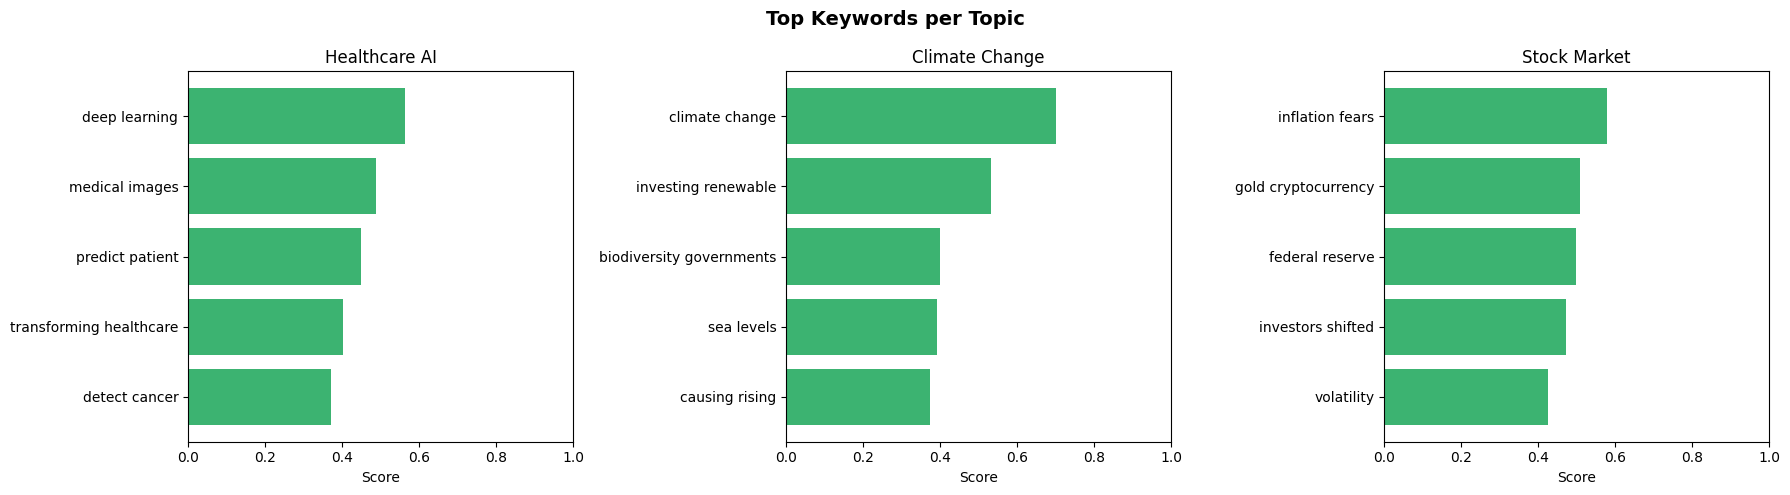

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, topic in enumerate(topics):
    df_topic = df_keywords[df_keywords["topic"] == topic].sort_values("score")
    axes[i].barh(df_topic["keyword"], df_topic["score"], color="mediumseagreen")
    axes[i].set_title(f"{topic}", fontsize=12)
    axes[i].set_xlabel("Score")
    axes[i].set_xlim(0, 1)

plt.suptitle("Top Keywords per Topic", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## WORD CLOUD

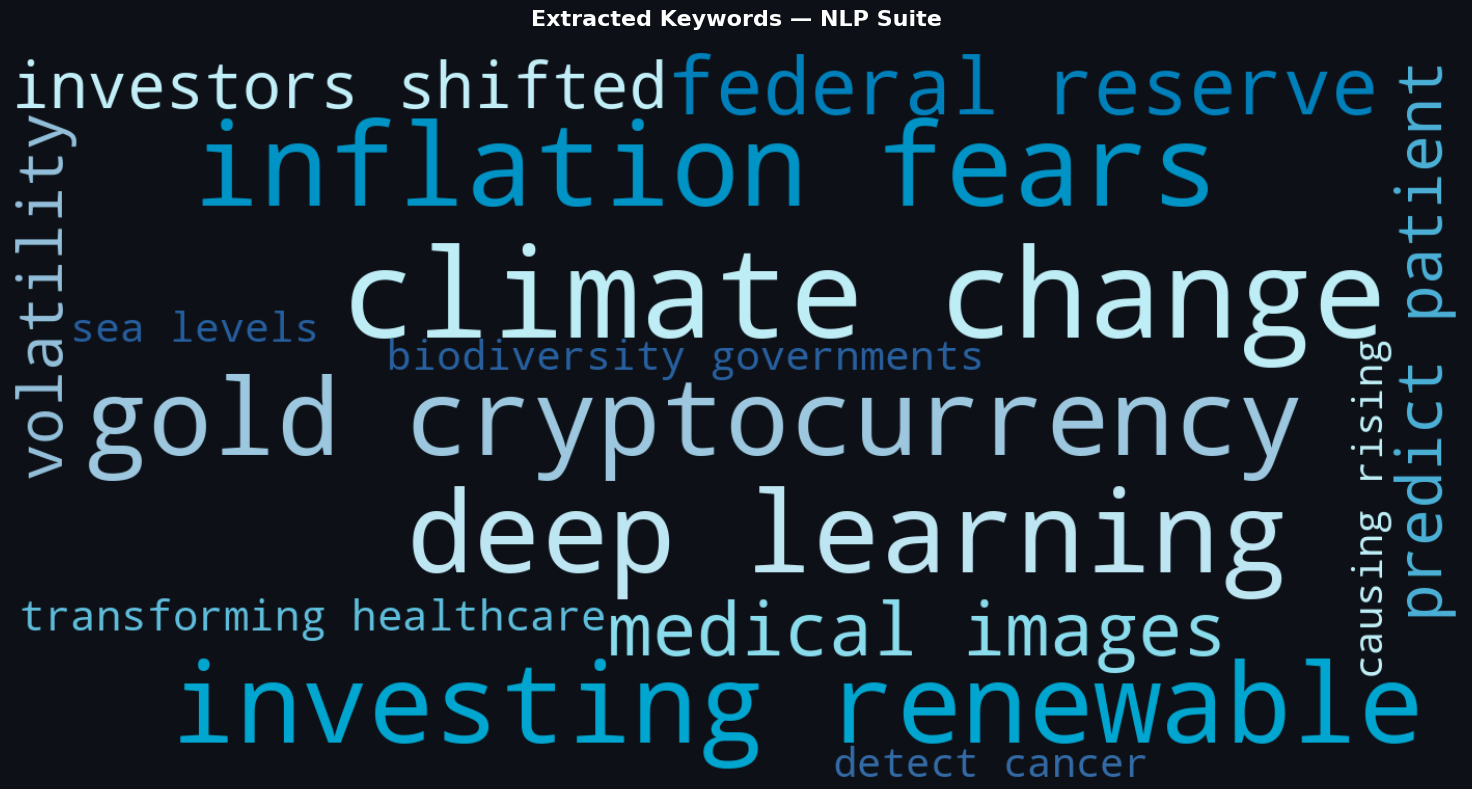

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Custom color palette — professional dark theme
colors = ["#00B4D8", "#0077B6", "#90E0EF", "#CAF0F8", "#023E8A"]
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

# Build keyword frequency dict
keyword_dict = {row["keyword"]: row["score"] for _, row in df_keywords.iterrows()}

# Generate word cloud
wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="#0D1117",   # dark github-style background
    colormap=custom_cmap,
    max_words=50,
    prefer_horizontal=0.85,
    min_font_size=12,
    max_font_size=120,
    collocations=False
).generate_from_frequencies(keyword_dict)

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")
plt.title("Extracted Keywords — NLP Suite",
          fontsize=16,
          fontweight="bold",
          color="white",
          pad=20)
plt.tight_layout()
plt.show()

## Keyword Score Heatmap

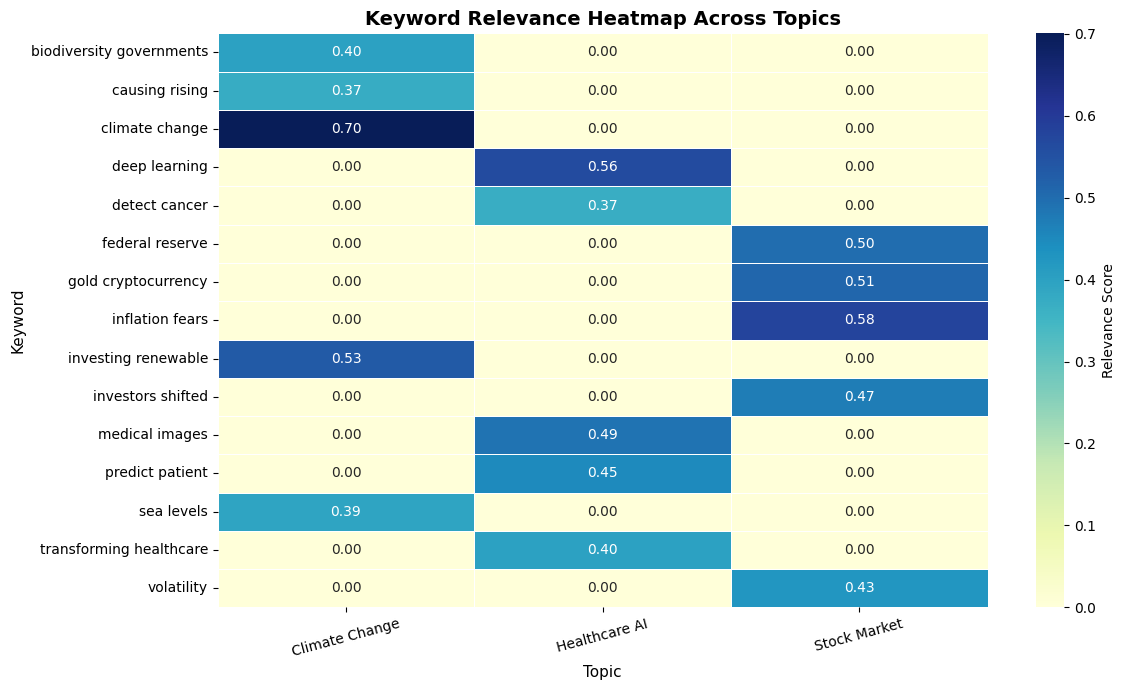

In [12]:
# Cell 10 — Keyword Heatmap
pivot = df_keywords.pivot(index="keyword", columns="topic", values="score").fillna(0)

plt.figure(figsize=(12, 7))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Relevance Score"}
)
plt.title("Keyword Relevance Heatmap Across Topics", fontsize=14, fontweight="bold")
plt.xlabel("Topic", fontsize=11)
plt.ylabel("Keyword", fontsize=11)
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
def extract_keywords(text: str, top_n: int = 5) -> list:
    """
    Input  : raw text string
    Output : list of tuples [(keyword, score), ...]
    """
    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=top_n,
        use_mmr=True,
        diversity=0.5
    )
    return keywords

# Test
sample = """Python is a popular programming language used in
data science, machine learning, and web development."""

results = extract_keywords(sample)
print("Test Results:")
for kw, score in results:
    print(f"  {kw:<25} {score:.4f}")

Test Results:
  python popular            0.7546
  python                    0.6968
  programming language      0.5290
  web development           0.3555
  used data                 0.1132


## Summary

In [11]:
print("=" * 45)
print("  Notebook 3 Complete: KeyBERT Keywords")
print("=" * 45)
print(f"  Texts analyzed       : {len(texts)}")
print(f"  Total keywords found : {len(df_keywords)}")
print(f"  Avg keyword score    : {round(df_keywords['score'].mean(), 4)}")
print(f"  Best keyword         : {df_keywords.loc[df_keywords['score'].idxmax(), 'keyword']}")
print()
print("  ✅ extract_keywords() ready for utils/")
print("  ✅ Ready to push to GitHub")

  Notebook 3 Complete: KeyBERT Keywords
  Texts analyzed       : 3
  Total keywords found : 15
  Avg keyword score    : 0.4774
  Best keyword         : climate change

  ✅ extract_keywords() ready for utils/
  ✅ Ready to push to GitHub
